<a href="https://colab.research.google.com/github/RolandCoku/Computer-Vision/blob/main/Exercise_3_Image_Classification_Roland_Coku.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3 - Image Classification

**Roland Çoku**  
Master's in Artificial Intelligence and Optimization  
Polytechnic University of Tirana

This notebook solves Exercise 3 for the Computer Vision course.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skimage import exposure, img_as_float, io
from skimage.color import label2rgb, rgb2gray
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects


plt.rcParams["figure.figsize"] = (8, 6)


## 1. Load Image

The image is loaded directly from the course GitHub repository.


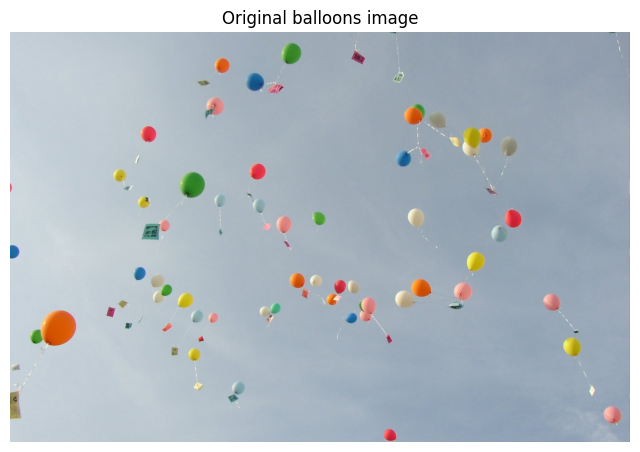

Image shape: (1058, 1600, 3)
Pixel range: 0 to 255
Data type: uint8


In [2]:
image_url = "https://raw.githubusercontent.com/xtianu/CV_Tirana_2026/main/M3_Image%20Classification/baloons.jpg"

image = io.imread(image_url)
image_float = img_as_float(image)

plt.imshow(image)
plt.title("Original balloons image")
plt.axis("off")
plt.show()

print("Image shape:", image.shape)
print("Pixel range:", image.min(), "to", image.max())
print("Data type:", image.dtype)


## 2. Convert from RGB to Grayscale


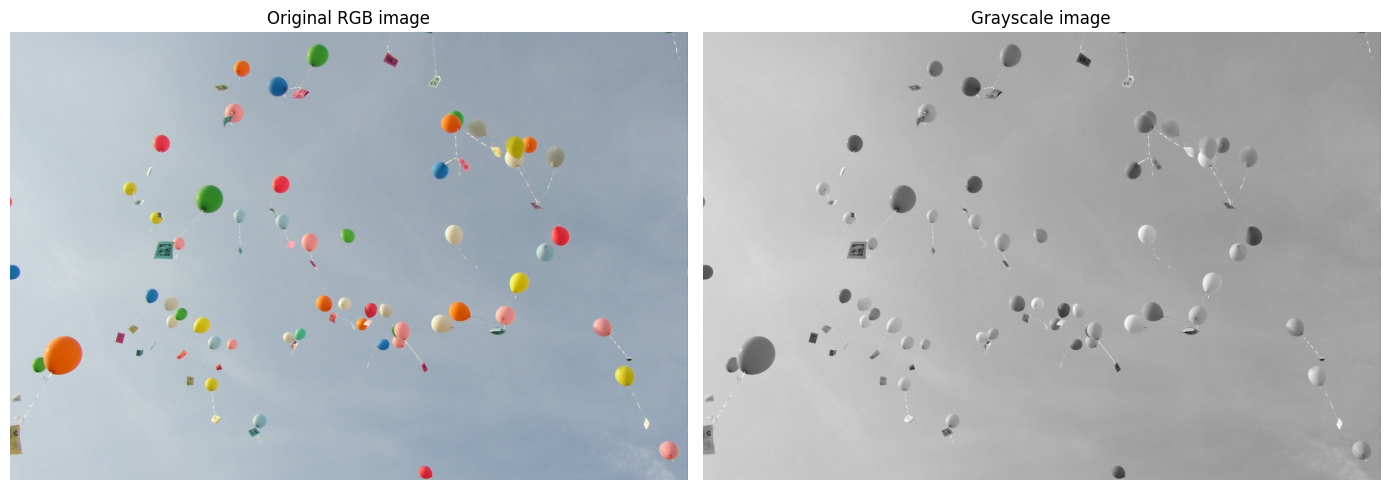

In [3]:
gray_image = rgb2gray(image_float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(image)
axes[0].set_title("Original RGB image")
axes[0].axis("off")

axes[1].imshow(gray_image, cmap="gray")
axes[1].set_title("Grayscale image")
axes[1].axis("off")

plt.tight_layout()
plt.show()


The RGB image contains three color channels. The grayscale image combines these channels into one intensity image, which is useful for thresholding.


## 3. Gamma Correction with γ = 0.5


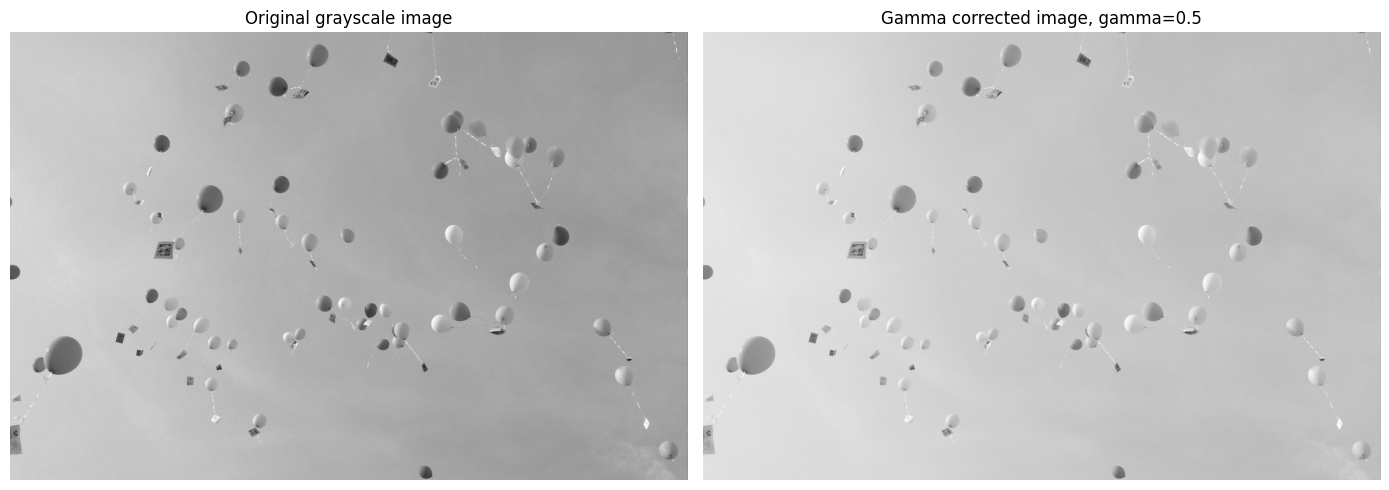

In [4]:
gamma_value = 0.5
gamma_corrected = exposure.adjust_gamma(gray_image, gamma=gamma_value)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(gray_image, cmap="gray")
axes[0].set_title("Original grayscale image")
axes[0].axis("off")

axes[1].imshow(gamma_corrected, cmap="gray")
axes[1].set_title("Gamma corrected image, gamma=0.5")
axes[1].axis("off")

plt.tight_layout()
plt.show()


Gamma correction with γ = 0.5 brightens the image. This changes the contrast between the balloons and the sky background.


## 4. Otsu Threshold from Grayscale Image


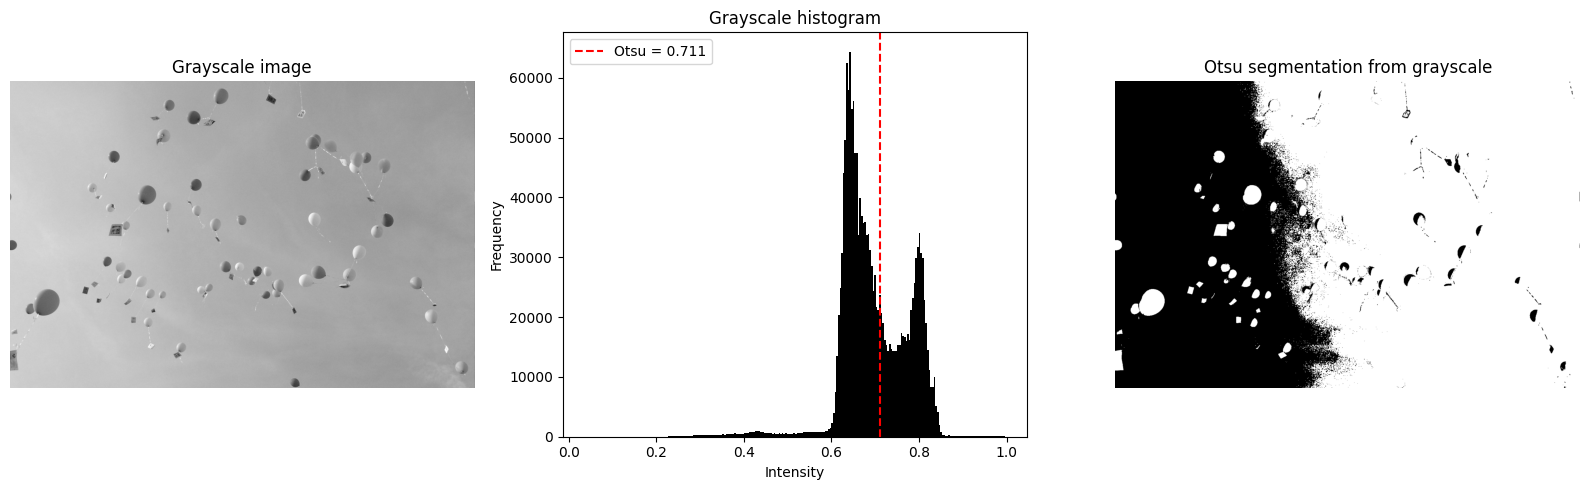

Otsu threshold: 0.7109542057291668


In [5]:
otsu_threshold = threshold_otsu(gray_image)
binary_gray = gray_image < otsu_threshold

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(gray_image, cmap="gray")
axes[0].set_title("Grayscale image")
axes[0].axis("off")

axes[1].hist(gray_image.ravel(), bins=256, color="black")
axes[1].axvline(otsu_threshold, color="red", linestyle="--", label=f"Otsu = {otsu_threshold:.3f}")
axes[1].set_title("Grayscale histogram")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Frequency")
axes[1].legend()

axes[2].imshow(binary_gray, cmap="gray")
axes[2].set_title("Otsu segmentation from grayscale")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Otsu threshold:", otsu_threshold)


The balloons are generally darker or more saturated than the sky, so the foreground is selected with values below the Otsu threshold. Some bright balloons may be less visible because grayscale thresholding only uses intensity, not color.


## 5. Apply Otsu Threshold to the Gamma-Corrected Image


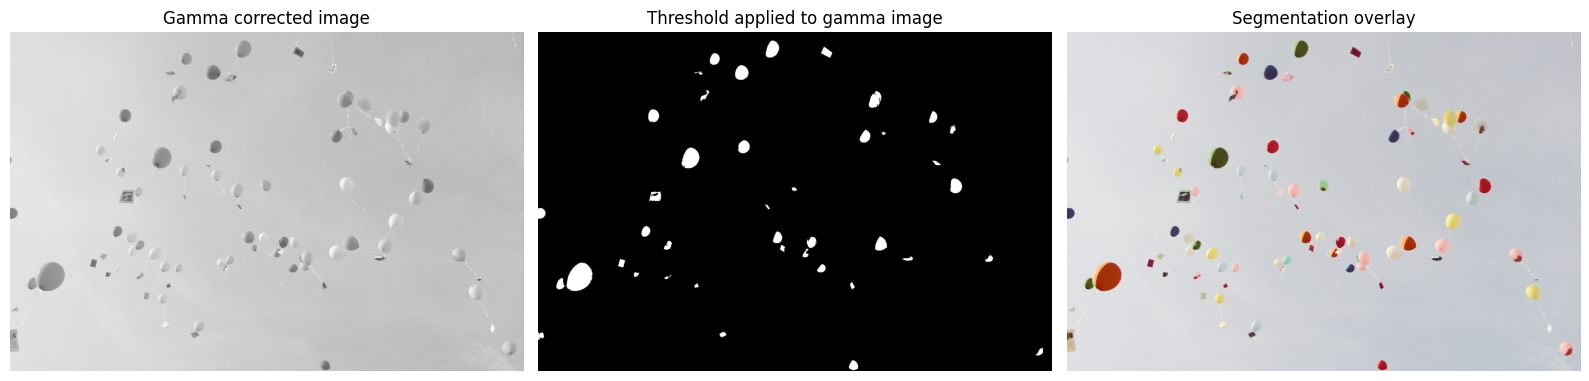

In [6]:
binary_gamma = gamma_corrected < otsu_threshold
binary_gamma = remove_small_objects(binary_gamma, min_size=80)
binary_gamma = remove_small_holes(binary_gamma, area_threshold=80)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(gamma_corrected, cmap="gray")
axes[0].set_title("Gamma corrected image")
axes[0].axis("off")

axes[1].imshow(binary_gamma, cmap="gray")
axes[1].set_title("Threshold applied to gamma image")
axes[1].axis("off")

axes[2].imshow(image)
axes[2].imshow(binary_gamma, cmap="Reds", alpha=0.45)
axes[2].set_title("Segmentation overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()


Applying the threshold to the gamma-corrected image changes the detected foreground regions. The mask contains candidate balloons and other dark objects such as tags or strings.


## 6. Label the Objects


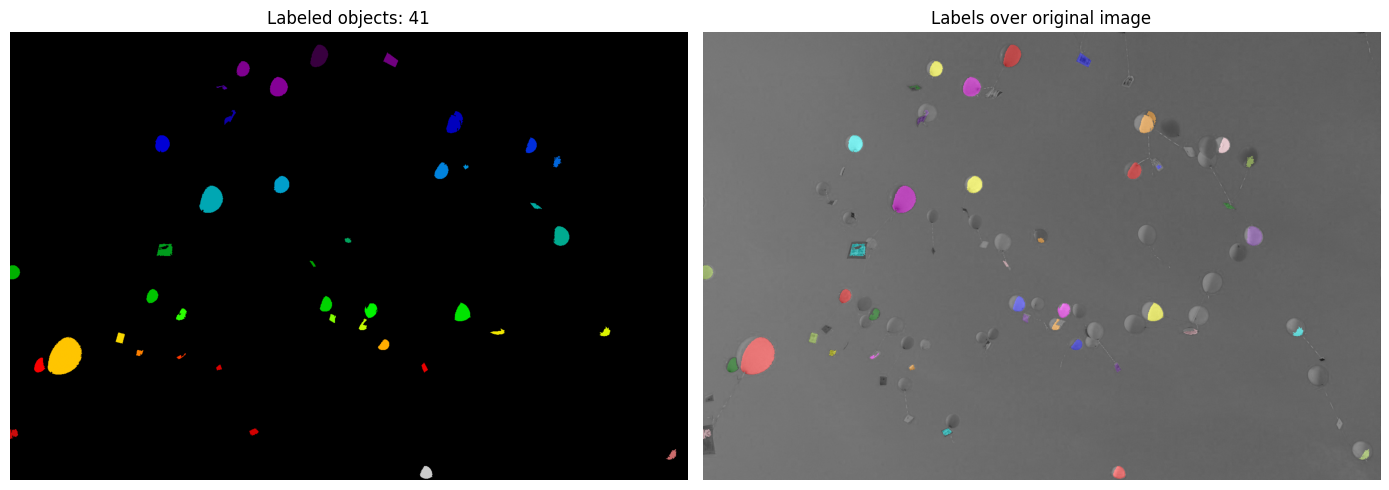

Number of labeled objects: 41


In [7]:
labeled_image = label(binary_gamma)
number_of_objects = labeled_image.max()
labeled_overlay = label2rgb(labeled_image, image=image_float, bg_label=0, alpha=0.45)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(labeled_image, cmap="nipy_spectral")
axes[0].set_title(f"Labeled objects: {number_of_objects}")
axes[0].axis("off")

axes[1].imshow(labeled_overlay)
axes[1].set_title("Labels over original image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Number of labeled objects:", number_of_objects)


Connected-component labeling assigns a unique integer label to each connected foreground region. These labeled regions can then be measured and filtered.


## 7. Extract Regional Properties

Extract area and eccentricity for each labeled object.


In [8]:
properties = regionprops_table(
    labeled_image,
    intensity_image=gray_image,
    properties=["label", "area", "eccentricity", "centroid", "major_axis_length", "minor_axis_length", "mean_intensity"],
)

features = pd.DataFrame(properties)
features.head()


,label,area,eccentricity,centroid-0,centroid-1,major_axis_length,minor_axis_length,mean_intensity
0,1,1622.0,0.735710,56.826141,729.127620,55.533367,37.612553,0.436507
1,2,646.0,0.777132,66.329721,898.193498,37.066186,23.327143,0.291393
2,3,861.0,0.604908,87.152149,549.658537,37.210963,29.630912,0.444943
3,4,1487.0,0.443437,129.580363,633.598521,46.075149,41.297405,0.338832
4,5,102.0,0.948456,130.343137,501.813725,26.762258,8.481200,0.405162


           label         area  eccentricity   centroid-0   centroid-1  \
count  41.000000    41.000000     41.000000    41.000000    41.000000   
mean   21.000000   730.658537      0.716784   542.401079   721.873230   
std    11.979149   893.956783      0.146451   271.975283   395.947714   
min     1.000000    82.000000      0.343741    56.826141     8.036066   
25%    11.000000   236.000000      0.621118   318.170732   404.780142   
50%    21.000000   466.000000      0.699902   623.565154   729.127620   
75%    31.000000   861.000000      0.813484   739.203863  1018.163774   
max    41.000000  5230.000000      0.953996  1040.760369  1562.591216   

       major_axis_length  minor_axis_length  mean_intensity  
count          41.000000          41.000000       41.000000  
mean           34.430023          23.113354        0.401030  
std            15.238692          12.945055        0.049622  
min            11.821009           6.236807        0.291393  
25%            26.180286        

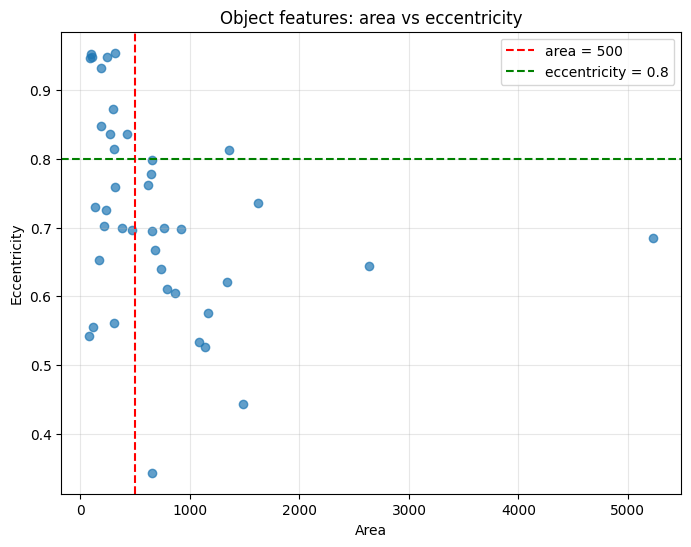

In [10]:
print(features.describe())

plt.figure(figsize=(8, 6))
plt.scatter(features["area"], features["eccentricity"], alpha=0.7)
plt.axvline(500, color="red", linestyle="--", label="area = 500")
plt.axhline(0.8, color="green", linestyle="--", label="eccentricity = 0.8")
plt.xlabel("Area")
plt.ylabel("Eccentricity")
plt.title("Object features: area vs eccentricity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Area measures the size of each region. Eccentricity measures how elongated a region is. Round objects have lower eccentricity, while strings and tags tend to have higher eccentricity.


## 8. Find Balloons

Balloons are selected as objects with area greater than 500 pixels and eccentricity lower than 0.8.


In [11]:
balloon_features = features[(features["area"] > 500) & (features["eccentricity"] < 0.8)]
balloon_labels = balloon_features["label"].to_numpy()

balloon_mask = np.isin(labeled_image, balloon_labels)

print("Number of detected balloons:", len(balloon_labels))
balloon_features


Number of detected balloons: 19


,label,area,eccentricity,centroid-0,centroid-1,major_axis_length,minor_axis_length,mean_intensity
0,1,1622.0,0.735710,56.826141,729.127620,55.533367,37.612553,0.436507
1,2,646.0,0.777132,66.329721,898.193498,37.066186,23.327143,0.291393
2,3,861.0,0.604908,87.152149,549.658537,37.210963,29.630912,0.444943
3,4,1487.0,0.443437,129.580363,633.598521,46.075149,41.297405,0.338832
7,8,1080.0,0.534177,263.596296,359.075926,40.438997,34.186019,0.375466
8,9,655.0,0.797651,268.630534,1229.975573,37.798580,22.797056,0.427941
10,11,922.0,0.697442,328.644252,1018.163774,40.785395,29.228509,0.361490
12,13,1135.0,0.525778,360.309251,640.460793,41.286577,35.119273,0.362449
13,14,2633.0,0.644482,395.916445,474.539309,66.531622,50.871390,0.415434
15,16,1336.0,0.621118,482.012725,1300.303892,46.988757,36.825879,0.336741


The selected regions correspond to relatively large and round objects. This removes many small objects and elongated objects such as strings or paper tags.


## 9. Plot the Balloons


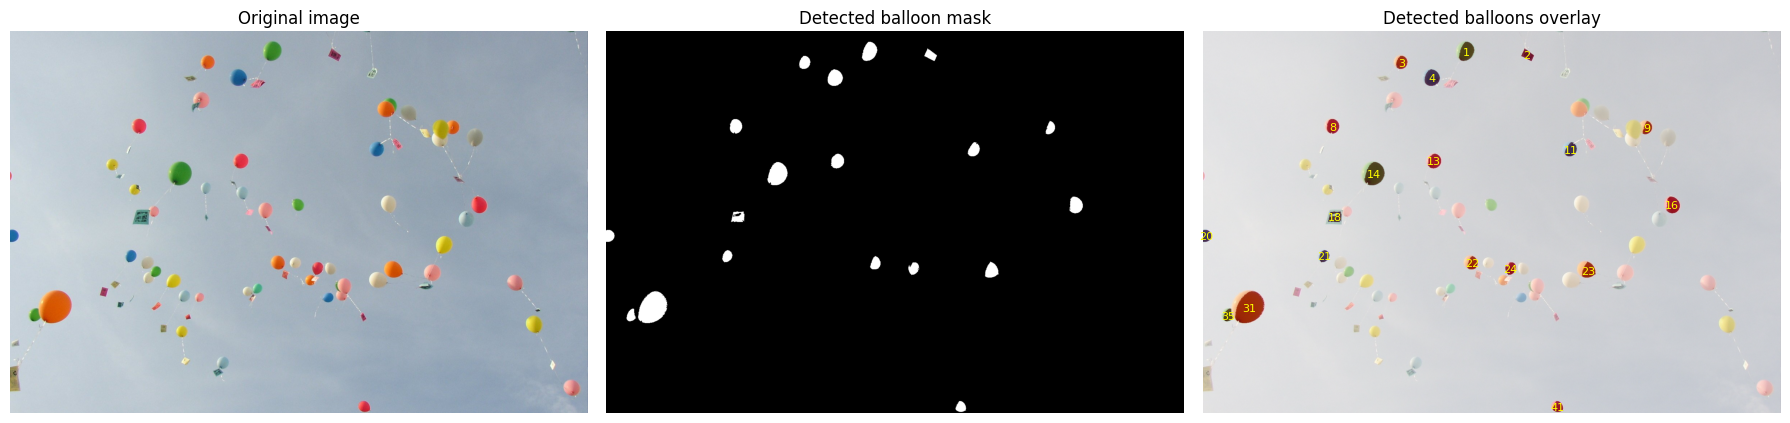

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(balloon_mask, cmap="gray")
axes[1].set_title("Detected balloon mask")
axes[1].axis("off")

axes[2].imshow(image)
axes[2].imshow(balloon_mask, cmap="Reds", alpha=0.5)
axes[2].set_title("Detected balloons overlay")
axes[2].axis("off")

for region in regionprops(labeled_image):
    if region.label in balloon_labels:
        y, x = region.centroid
        axes[2].text(x, y, str(region.label), color="yellow", fontsize=8, ha="center", va="center")

plt.tight_layout()
plt.show()
